# Housing Prices Predictive Supervised Machine Learning Model

## Problem Statement:Create a predictive model that can predict House Prices.By Developing a supervised machine learning predictive model capable of accurately estimating residential property prices based on key housing characteristics such as square footage, number of bedrooms, number of bathrooms, year built, and neighborhood type. The objective is to analyze the relationship between these features and house prices to generate reliable price predictions for properties.

In [2]:
import pandas as pd
import numpy as np
Housing_Prices_Data=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Regression projects/Housing Prices Data/housing_price_dataset.csv")
print(Housing_Prices_Data.shape)
Housing_Prices_Data.drop_duplicates()
print(Housing_Prices_Data.shape)

(50000, 6)
(50000, 6)


In [3]:
Housing_Prices_Data.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


## Target Variable is Price.

<Axes: >

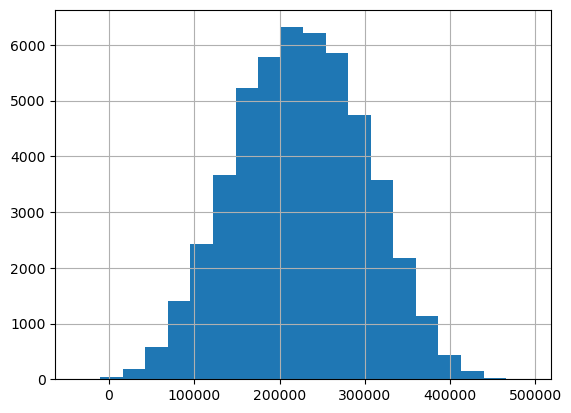

In [4]:
Housing_Prices_Data['Price'].hist(bins=20)

## Exploratory Data Analysis

In [5]:
Housing_Prices_Data.nunique()

SquareFeet       2000
Bedrooms            4
Bathrooms           3
Neighborhood        3
YearBuilt          72
Price           50000
dtype: int64

In [6]:
Housing_Prices_Data.columns

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt',
       'Price'],
      dtype='object')

### CategoricalColumns:['YearBuilt','Bedrooms', 'Bathrooms', 'Neighborhood']
### ContinousColumns:['SquareFeet','Price']


In [7]:
Housing_Prices_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [8]:
Housing_Prices_Data.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


## Uni Variate Analysis by Histogram

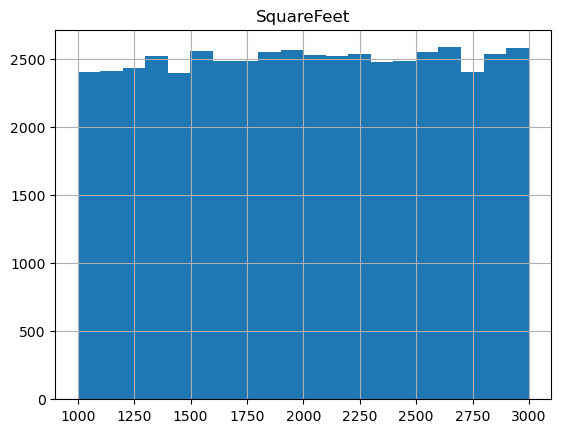

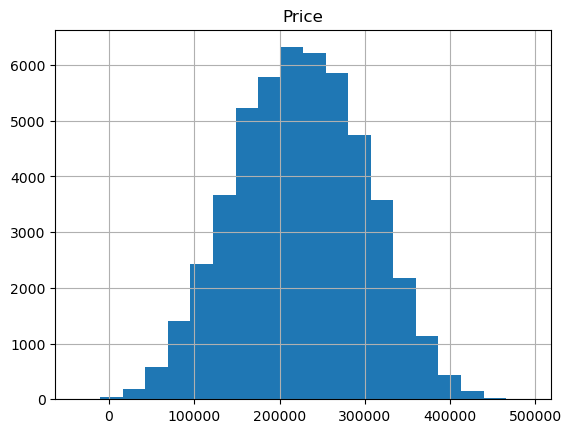

In [11]:
ContinousColumns=['SquareFeet','Price']
for cols in ContinousColumns:
    Housing_Prices_Data.hist(cols,bins=20)

## No Need for outlier treatment

## Uni Variate Analysis by Bar Charts

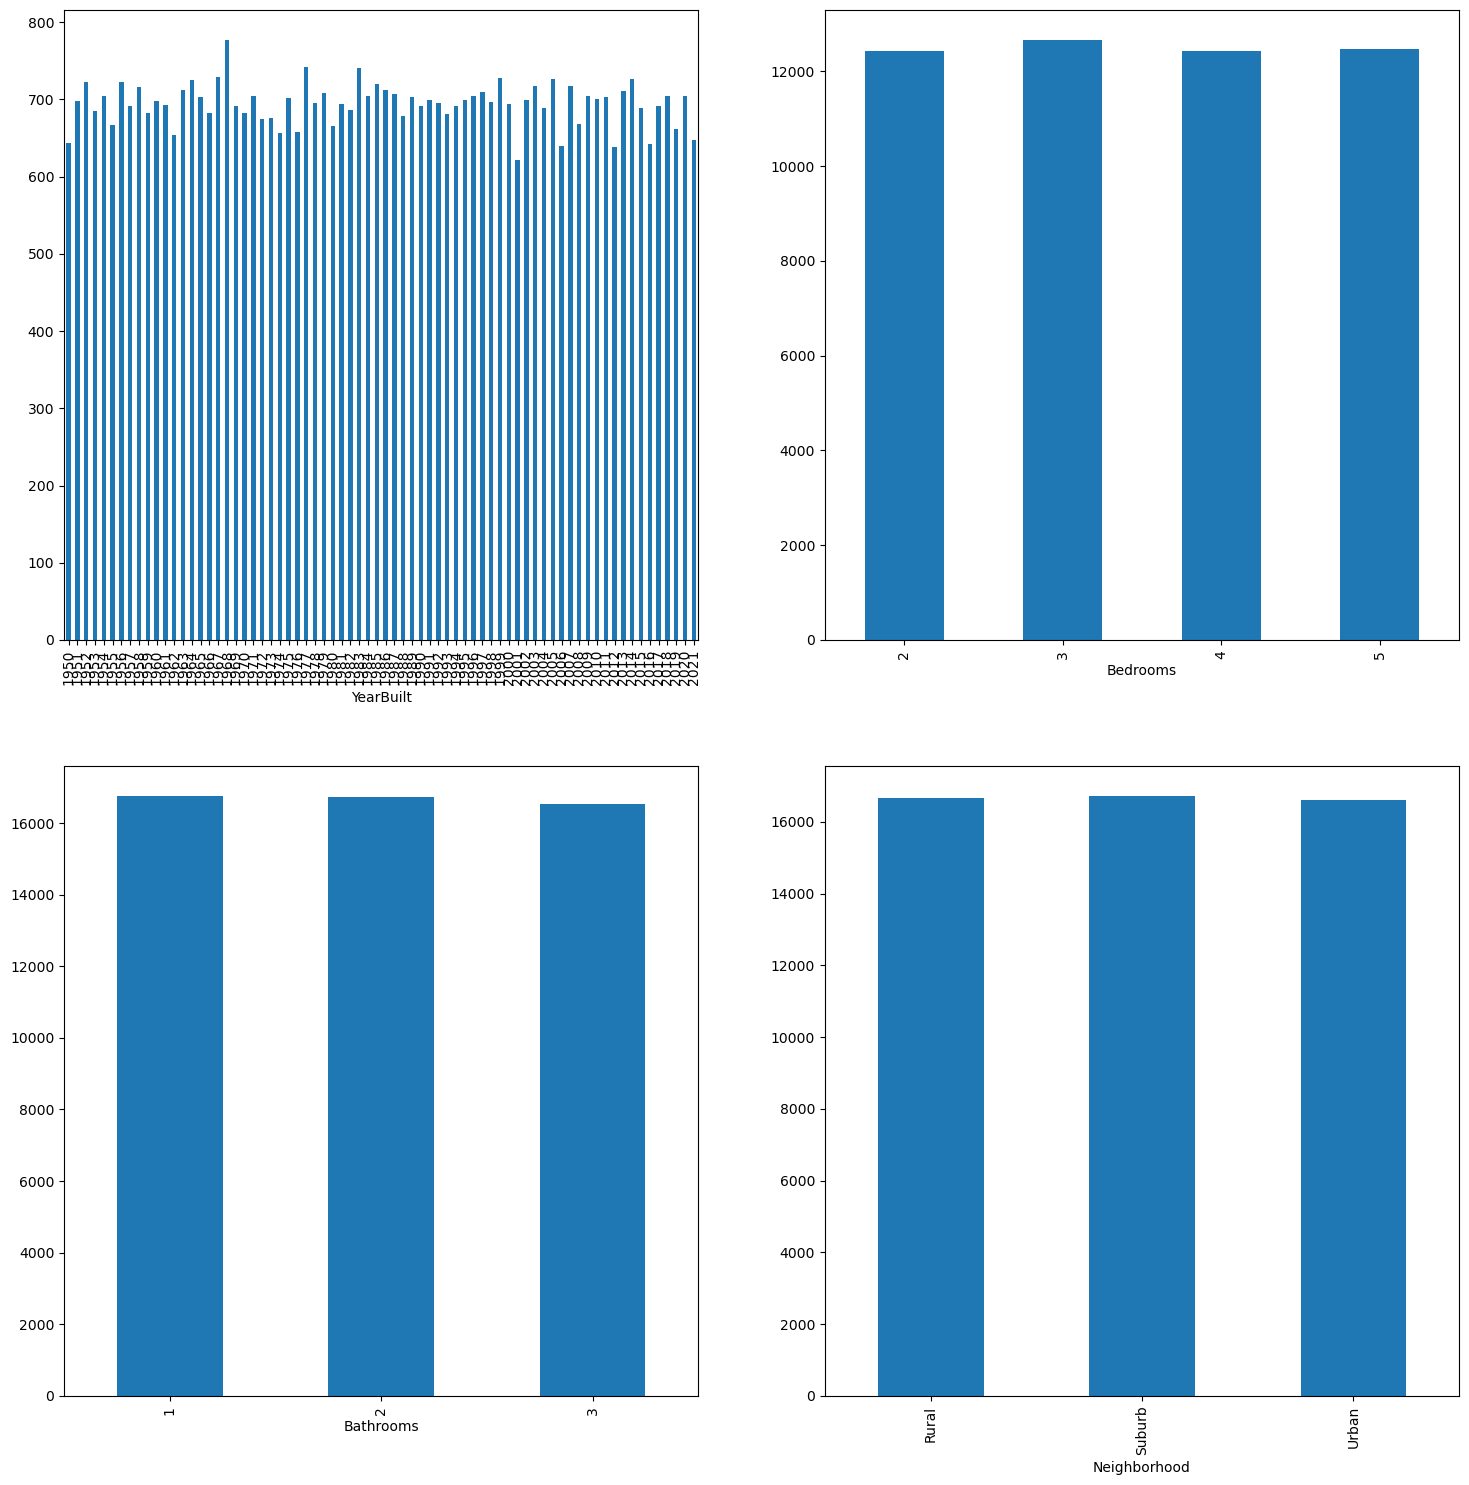

In [16]:
categoricalColumns=['YearBuilt','Bedrooms', 'Bathrooms', 'Neighborhood']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,2,figsize=(18,18))
subplots=subplots.flatten()
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Housing_Prices_Data.groupby(cols).size().plot(ax=subplots[no_of_cols],kind='bar')


### No need for Imbalance treatment

### Missing value treatment is not needed.

In [20]:
Housing_Prices_Data.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

## Continuous Vs Continuous -- Scatter Charts

<Axes: xlabel='SquareFeet', ylabel='Price'>

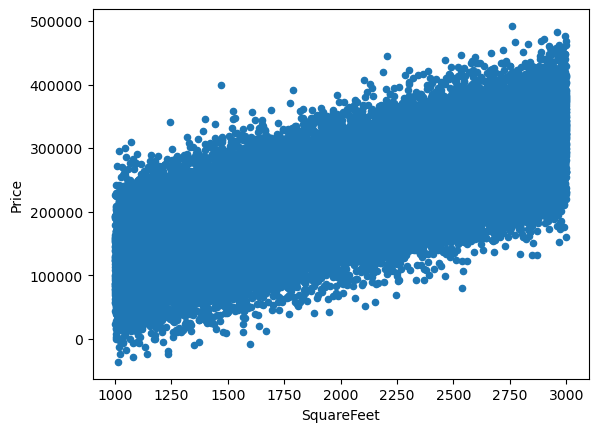

In [23]:
Housing_Prices_Data.plot.scatter(x='SquareFeet',y='Price')

## Statistical Feature Selection (Continuous Vs Continuous) using Correlation value

In [25]:
ContinousColumns=['SquareFeet','Price']
corr_data=Housing_Prices_Data[ContinousColumns].corr()
corr_data

,SquareFeet,Price
SquareFeet,1.00000,0.75072
Price,0.75072,1.00000


### SquareFeet is highly correlated with Price

## Categorical Vs Continuous -- Box Plots

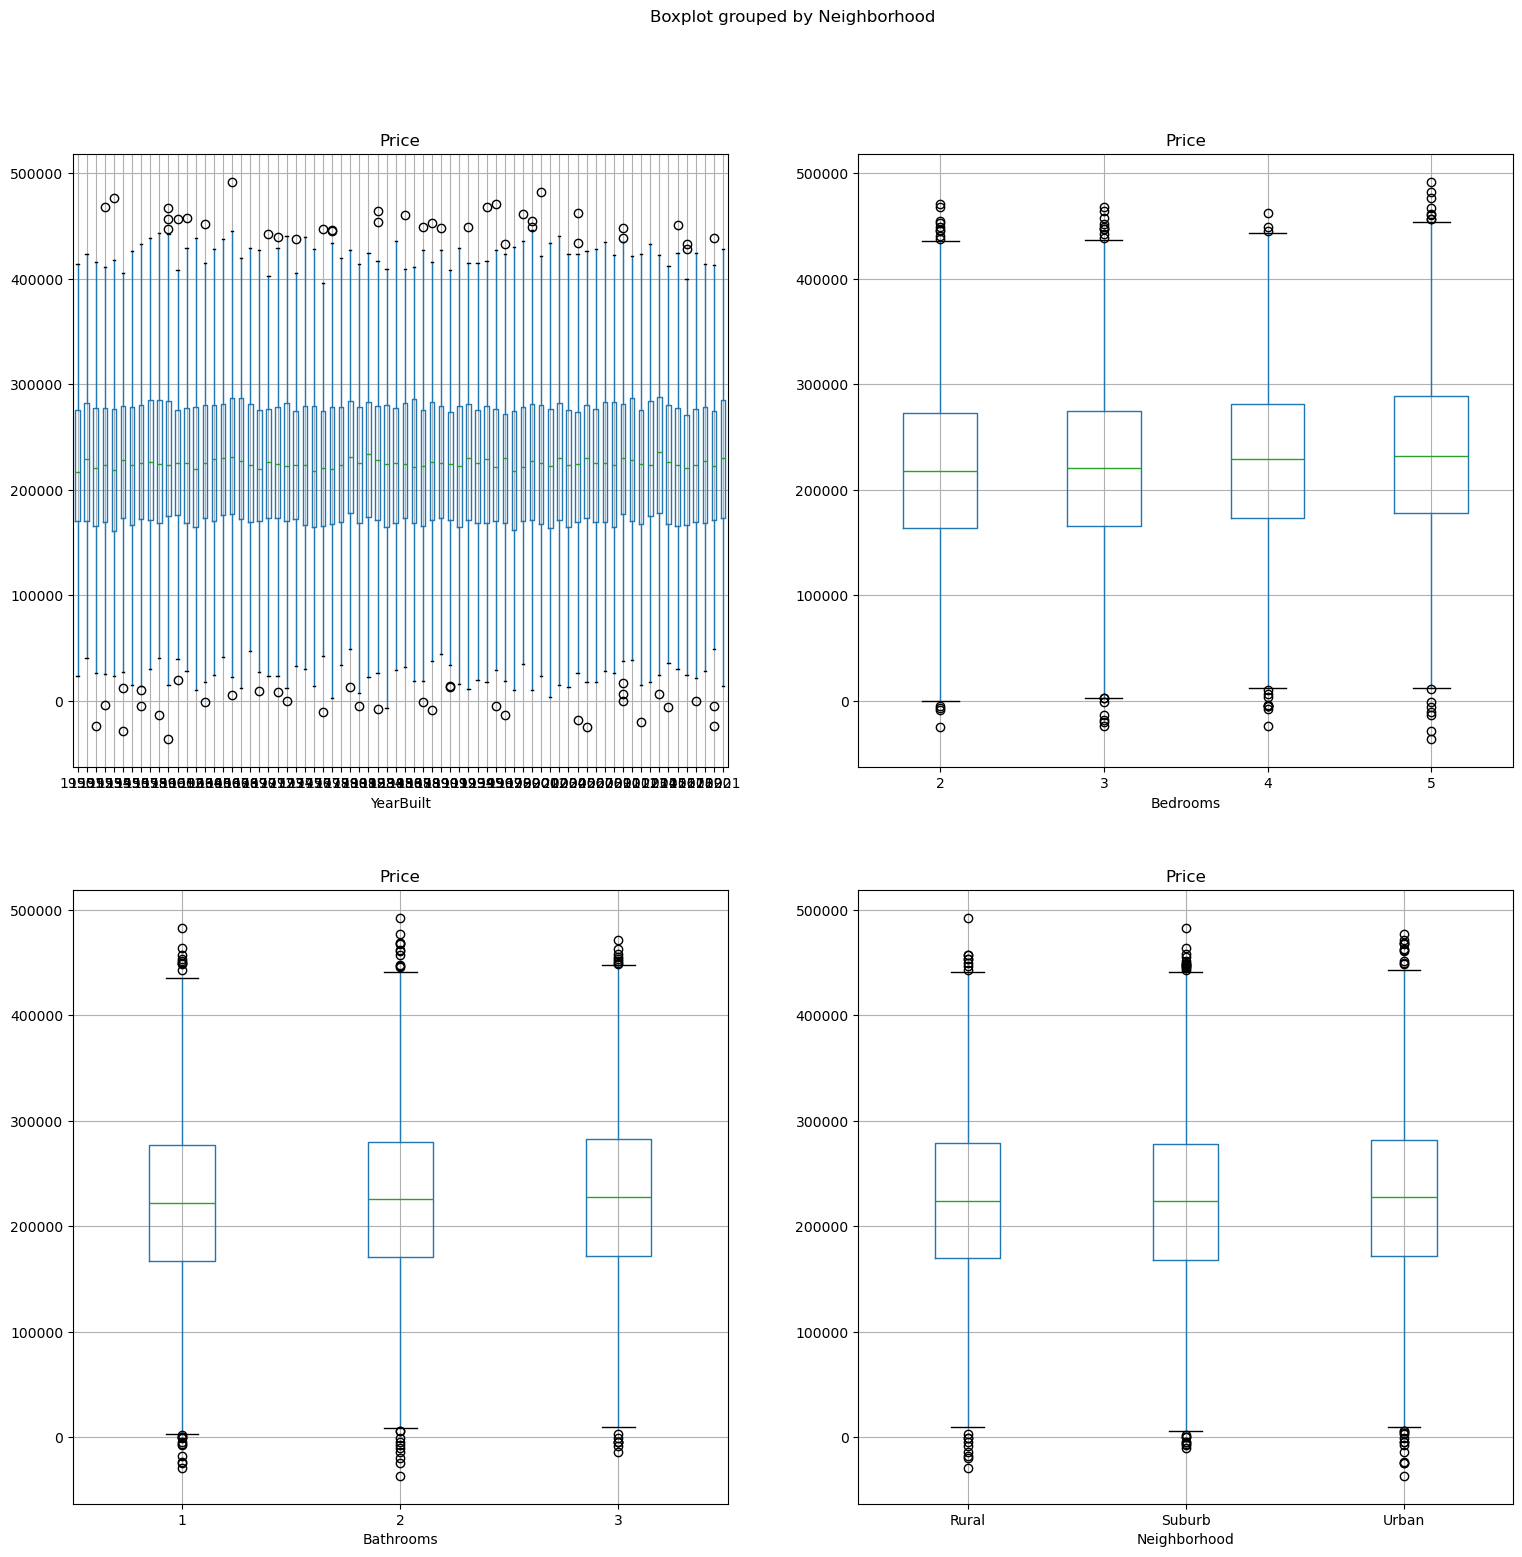

In [27]:
CategoricalColumns=['YearBuilt','Bedrooms', 'Bathrooms', 'Neighborhood']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,2,figsize=(18,18))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    Housing_Prices_Data.boxplot(column='Price',by=cols,vert=True,ax=subplots[no_of_cols])

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [30]:
CategoricalColumns=['YearBuilt','Bedrooms', 'Bathrooms', 'Neighborhood']
def functionAnova(data, targetVariable,CategoricalColumns):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in CategoricalColumns:
        CategoricalGroupLists=data.groupby(cols)[targetVariable].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            SelectedPredictors.append(cols)
            print('Price is correlated with ',cols, 'and p value is ',AnovaResults[1])
        else:
            print('Price is not  correlated with ',cols, 'and p value is ',AnovaResults[1])
    return SelectedPredictors
functionAnova(Loan_Risk_Data, 'Price',CategoricalColumns)

Price is not  correlated with  YearBuilt and p value is  0.5603801148015934
Price is correlated with  Bedrooms and p value is  3.296682413911252e-58
Price is correlated with  Bathrooms and p value is  1.0883482514515201e-09
Price is correlated with  Neighborhood and p value is  4.71655914667263e-06


['Bedrooms', 'Bathrooms', 'Neighborhood']

In [31]:
Housing_Prices_Data.columns

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt',
       'Price'],
      dtype='object')

## Data Pre-processing for Machine Learning


In [34]:
SelectedColumns=['SquareFeet', 'Bedrooms', 'Bathrooms', 'Neighborhood', 'YearBuilt']
DataForML_Housing_Prices_Data=Housing_Prices_Data[SelectedColumns]
DataForML_Housing_Prices_Data.to_pickle('DataForML_Housing_Prices_Data.pkl')
DataForML_Housing_Prices_Data=pd.read_pickle('DataForML_Housing_Prices_Data.pkl')



## Converting the nominal variable to numeric using get_dummies()

In [35]:
DataForML_Housing_Prices_Data=pd.get_dummies(DataForML_Housing_Prices_Data)
DataForML_Housing_Prices_Data.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,True,False,False
1,2459,3,2,1980,True,False,False
2,1860,2,1,1970,False,True,False
3,2294,2,1,1996,False,False,True
4,2130,5,2,2001,False,True,False


## Converting the binary nominal variable to numeric using 1/0 mapping

In [36]:
DataForML_Housing_Prices_Data.replace({True:1,False:0},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_189160\12517060.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForML_Housing_Prices_Data.replace({True:1,False:0},inplace=True)


In [37]:
DataForML_Housing_Prices_Data.shape

(50000, 7)

In [38]:
DataForML_Housing_Prices_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   SquareFeet           50000 non-null  int64
 1   Bedrooms             50000 non-null  int64
 2   Bathrooms            50000 non-null  int64
 3   YearBuilt            50000 non-null  int64
 4   Neighborhood_Rural   50000 non-null  int64
 5   Neighborhood_Suburb  50000 non-null  int64
 6   Neighborhood_Urban   50000 non-null  int64
dtypes: int64(7)
memory usage: 2.7 MB


In [ ]:
pd.set_option('Display.max_columns',False)

In [39]:
DataForML_Housing_Prices_Data['Price']=Housing_Prices_Data['Price']
DataForML_Housing_Prices_Data.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,Price
0,2126,4,1,1969,1,0,0,215355.283618
1,2459,3,2,1980,1,0,0,195014.221626
2,1860,2,1,1970,0,1,0,306891.012076
3,2294,2,1,1996,0,0,1,206786.787153
4,2130,5,2,2001,0,1,0,272436.239065


In [ ]:
pd.set_option('display.max_columns',None)

In [40]:
DataForML_Housing_Prices_Data.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,Price
0,2126,4,1,1969,1,0,0,215355.283618
1,2459,3,2,1980,1,0,0,195014.221626
2,1860,2,1,1970,0,1,0,306891.012076
3,2294,2,1,1996,0,0,1,206786.787153
4,2130,5,2,2001,0,1,0,272436.239065


In [41]:
DataForML_Housing_Prices_Data.shape

(50000, 8)

In [100]:
DataForML_Housing_Prices_Data.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,Price
0,2126,4,1,1969,1,0,0,215355.283618
1,2459,3,2,1980,1,0,0,195014.221626
2,1860,2,1,1970,0,1,0,306891.012076
3,2294,2,1,1996,0,0,1,206786.787153
4,2130,5,2,2001,0,1,0,272436.239065


## Splitting the data into Training and Testing sample

In [42]:
DataForML_Housing_Prices_Data.columns

Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt',
       'Neighborhood_Rural', 'Neighborhood_Suburb', 'Neighborhood_Urban',
       'Price'],
      dtype='object')

In [94]:

predictors=['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt',
       'Neighborhood_Rural', 'Neighborhood_Suburb', 'Neighborhood_Urban']

targetVariable='Price'
X=DataForML_Housing_Prices_Data[predictors].values
y=DataForML_Housing_Prices_Data[targetVariable].values
#from sklearn.preprocessing import PolynomialFeatures
#poly=PolynomialFeatures(degree=2,include_bias=False)
#X=poly.fit_transform(X)
#predictors=poly.get_feature_names_out()

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)



print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(40000, 7)
(40000,)
(10000, 7)
(10000,)


In [ ]:
DataForMLLoan_Risk_Data_Numeric.head()

## Linear Regression

In [96]:
from sklearn.linear_model import LinearRegression
RegModel=LinearRegression()
LREG=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',(metrics.r2_score(y_train,LREG.predict(X_train))))
prediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults['Predicted',targetVariable]=prediction
TestingDataResults.head()
TestingDataResults['APE']=100*(abs(TestingDataResults['Predicted',targetVariable]-TestingDataResults[targetVariable])/TestingDataResults[targetVariable])
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
def AccuracyScore(orig,pred):
    MAPE=np.mean((abs(orig-pred)/orig)*100)
    return 100-MAPE
from sklearn.metrics import make_scorer
custom_scoring=make_scorer(AccuracyScore,greater_is_better=True) 
from sklearn.model_selection import cross_val_score
AccuracyScore=cross_val_score(LREG,X,y,cv=5,scoring=custom_scoring)
print(AccuracyScore)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyScore),2),'%')


R2 Value: 0.57072217526748
80.647199104129
85.11523833568839
[77.17604815 76.46723035 78.48072219 78.71684403 69.01241654]
Final Accuracy of the Model: 75.97 %


## Decision Tree

R2 Value: 0.5643651947715229
84.88980454022773
84.88980454022773
[99.76842347 99.75738746 99.78090214 99.785057   99.67755945]
Final Accuracy of the Model: 99.75 %


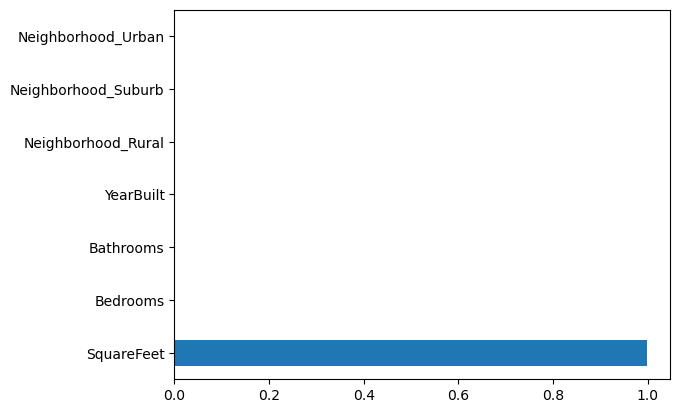

In [97]:
from sklearn.tree import DecisionTreeRegressor
RegModel=DecisionTreeRegressor(max_depth=4,criterion='squared_error')
DT=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',(metrics.r2_score(y_train,DT.predict(X_train))))
Feature_Importances=pd.Series(DT.feature_importances_,index=predictors)
Feature_Importances.nlargest(10).plot(kind='barh')
prediction=DT.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults['Predicted',targetVariable]=prediction
TestingDataResults.head()
TestingDataResults['APE']=100*(abs(TestingDataResults['Predicted',targetVariable]-TestingDataResults[targetVariable])/TestingDataResults[targetVariable])
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=MAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)
def AccuracyScore(orig,pred):
    MAPE=np.mean(abs(orig-pred)/orig)
    return 100-MAPE
from sklearn.metrics import make_scorer
custom_scoring=make_scorer(AccuracyScore,greater_is_better=True) 
from sklearn.model_selection import cross_val_score
AccuracyScore=cross_val_score(DT,X,y,cv=5,scoring=custom_scoring)
print(AccuracyScore)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyScore),2),'%')


## Random Forest Regressor

RandomForestRegressor(n_estimators=200)
R2 Value: 0.9327914782469342
mse 2817614277.813305
Accuracy 71.34643916663356
0:01:47.148756


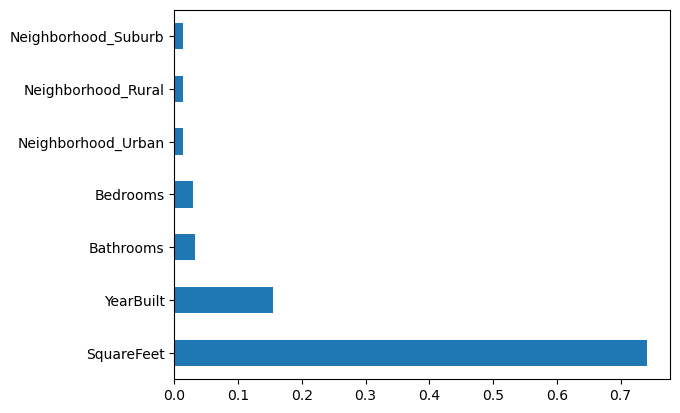

In [98]:
from datetime import datetime
start_time=datetime.now()

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
RegModel = RandomForestRegressor(n_estimators=200,criterion='squared_error')
 
#Printing all the parameters of Random Forest
print(RegModel)
 
#Creating the model on Training Data
RF=RegModel.fit(X_train,y_train)
prediction=RF.predict(X_test) 
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, RF.predict(X_train)))
mse = mean_squared_error(y_test, prediction)
print('mse',mse)
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

end_time=datetime.now()
et=end_time-start_time
print(et)

## XGBRegressor

XGBRegressor(base_score=None, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.094, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=11,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)
R2 Value: 0.9360393551726826
Final Accuracy of the Model: 70.0 %


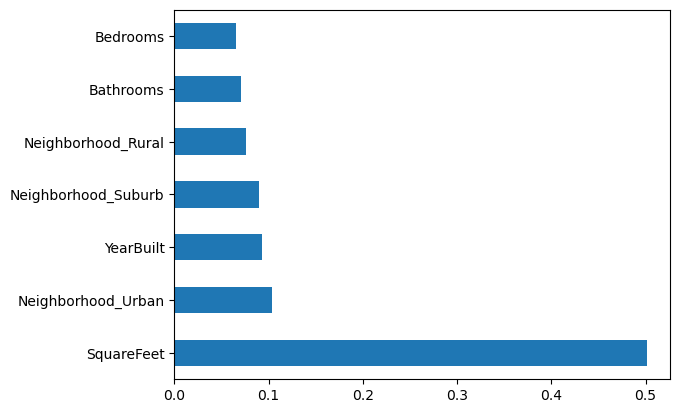

In [117]:
from xgboost import XGBRegressor
RegModel=XGBRegressor(max_depth=11, learning_rate=0.094, n_estimators=500, objective='reg:squarederror', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(RegModel)
 
#Creating the model on Training Data
XGB=RegModel.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics  
print('R2 Value:',metrics.r2_score(y_train, XGB.predict(X_train)))
 
#Measuring accuracy on Testing Data
#print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()
print('Final Accuracy of the Model:',round(100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100),0),'%')

## AdaBoost Regressor

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=1),
                  learning_rate=0.8, n_estimators=300)
R2 Value: 0.49070140699974407
Accuracy 68.22151625287879


,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,Price,PredictedPrice
0,1348,3,2,1963,1,0,0,145339.468576,167232.676800
1,1550,5,2,1969,0,1,0,154349.577317,181685.351794
2,2938,5,1,1986,0,1,0,409278.403922,282962.824361
3,2089,3,2,2007,0,1,0,298847.551848,261950.831243
4,2978,4,3,1986,1,0,0,258569.300834,282962.824361


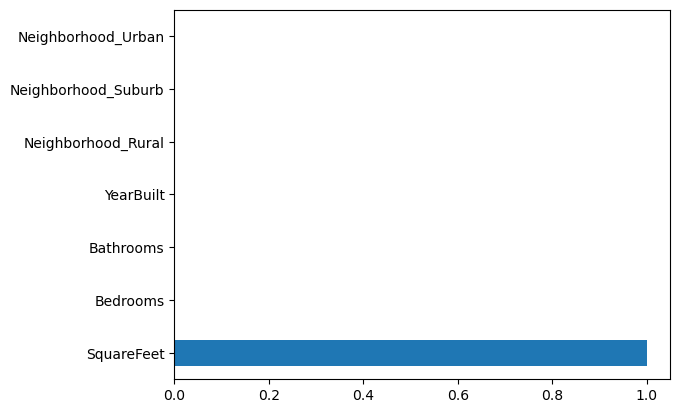

In [115]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
 
#Choosing Decision Tree with 1 level as the weak learner
DTR=DecisionTreeRegressor(max_depth=1)
RegModel = AdaBoostRegressor(n_estimators=300, estimator=DTR,learning_rate=0.8)
 
#Printing all the parameters of Adaboost
print(RegModel)
 
#Creating the model on Training Data
AB=RegModel.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring Goodness of fit in Training data
from sklearn import metrics
print('R2 Value:',metrics.r2_score(y_train, AB.predict(X_train)))
 
#Measuring accuracy on Testing Data
print('Accuracy',100- (np.mean(np.abs((y_test - prediction) / y_test)) * 100))
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors) 
TestingDataResults[targetVariable]=y_test
TestingDataResults[('Predicted'+targetVariable)]=prediction
TestingDataResults.head()

## XGBoost is selected for deploying and Model Deployment on Sample Data

In [101]:
NewData=pd.DataFrame(data=[
 [2126,4,1,1969,1,0,0],
 [2459,3,2,1980,1,0,0],
 [1860,2,1,1970,0,1,0],
 [2294,2,1,1996,0,0,1],
 [2130,5,2,2001,0,1,0],
 [1985,3,2,1988,1,0,0],
 [2750,4,3,2010,0,1,0],
 [1680,2,1,1975,0,0,1],
 [3100,5,4,2018,0,1,0],
 [2250,3,2,1992,1,0,0],
 [1850,2,2,1983,0,1,0],
 [2400,4,3,2005,0,0,1],
 [2050,3,2,1998,1,0,0],
 [1750,2,1,1978,0,1,0],
 [2950,5,3,2015,0,0,1],
 [2200,4,2,1990,1,0,0],
 [2600,4,3,2008,0,1,0],
 [1900,3,2,1986,0,0,1],
 [1700,2,1,1972,1,0,0],
 [2800,5,4,2020,0,1,0],
 [2300,4,2,1999,0,0,1],
 [2000,3,2,1985,1,0,0],
 [2500,4,3,2012,0,1,0],
 [1800,2,1,1977,0,0,1],
 [3200,5,4,2021,0,1,0],
 [2150,3,2,1994,1,0,0],
 [2700,4,3,2016,0,0,1],
 [1950,3,2,1981,0,1,0],
 [1600,2,1,1968,1,0,0],
 [3000,5,4,2019,0,1,0]
],columns=predictors)

In [102]:
newX=NewData.values

In [103]:
pred=XGB.predict(newX)

In [104]:
def GeneratePred(inpData):
    newX=inpData.values
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return (inpData) 




In [105]:
GeneratePred(inpData=NewData)

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,Prediction
0,2126,4,1,1969,1,0,0,223665.437500
1,2459,3,2,1980,1,0,0,215753.140625
2,1860,2,1,1970,0,1,0,207354.734375
3,2294,2,1,1996,0,0,1,208124.593750
4,2130,5,2,2001,0,1,0,252916.218750
5,1985,3,2,1988,1,0,0,214269.906250
6,2750,4,3,2010,0,1,0,245453.093750
7,1680,2,1,1975,0,0,1,182148.015625
8,3100,5,4,2018,0,1,0,335740.250000
9,2250,3,2,1992,1,0,0,240458.546875
